In [34]:
import pandas as pd
import numpy as np
import psycopg2
import sys
from pathlib import Path




In [35]:

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\keziah\Desktop\Skye8\Code\skye8-ngwa-densey\skye8-ds-ngwa-densey


In [36]:
from src.db import DB_CONFIG

print("Database configuration loaded.")

Database configuration loaded.


In [37]:
from importlib import reload
import src.db as db

reload(db)

DB_CONFIG = db.DB_CONFIG

print("Password loaded:", bool(DB_CONFIG.get("password")))

Password loaded: True


In [38]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))




conn = psycopg2.connect(**DB_CONFIG)

In [39]:
farms = pd.read_sql("SELECT * FROM farms", conn)
plots = pd.read_sql("SELECT * FROM plots", conn)
harvests = pd.read_sql("SELECT * FROM harvests", conn)

conn.close()

print("Farms:", farms.shape)
print("Plots:", plots.shape)
print("Harvests:", harvests.shape)

C:\Users\keziah\AppData\Local\Temp\ipykernel_22464\3713469120.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  farms = pd.read_sql("SELECT * FROM farms", conn)
C:\Users\keziah\AppData\Local\Temp\ipykernel_22464\3713469120.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plots = pd.read_sql("SELECT * FROM plots", conn)
C:\Users\keziah\AppData\Local\Temp\ipykernel_22464\3713469120.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  harvests = pd.read_sql("SELECT * FROM harvests", conn)


Farms: (420, 7)
Plots: (1817, 6)
Harvests: (11385, 13)


In [40]:
# Make copies so the original dataframes remain unchanged
farms_ml = farms.copy()
plots_ml = plots.copy()
harvests_ml = harvests.copy()

In [41]:
farm_plot = farms_ml.merge(
    plots_ml,
    on="farm_id",
    how="inner",
    validate="one_to_many"
)

print("Farm-plot merge successful.")
print("Rows:", len(farm_plot))
print("Columns:", len(farm_plot.columns))
print("Unique farms:", farm_plot["farm_id"].nunique())
print("Unique plots:", farm_plot["plot_id"].nunique())

Farm-plot merge successful.
Rows: 1817
Columns: 12
Unique farms: 420
Unique plots: 1817


In [42]:
model_table = farm_plot.merge(
    harvests_ml,
    on="plot_id",
    how="inner",
    validate="one_to_many"
)

print("Plot-harvest merge successful.")
print("Rows:", len(model_table))
print("Columns:", len(model_table.columns))
print("Unique farms:", model_table["farm_id"].nunique())
print("Unique plots:", model_table["plot_id"].nunique())
print("Unique harvests:", model_table["harvest_id"].nunique())

Plot-harvest merge successful.
Rows: 11385
Columns: 24
Unique farms: 420
Unique plots: 1817
Unique harvests: 11385


In [43]:
# Target and grouping key
TARGET = "met_target"
GROUP_KEY = "farm_id"

# Features available at or before planting
HONEST_FEATURES = [
    "village",
    "division",
    "soil_type",
    "altitude_m",
    "household_size",
    "extension_visits_yr",
    "area_ha",
    "crop",
    "slope_pct",
    "irrigated",
    "season",
    "planting_date",
    "seed_variety"
]

# Harvest-time features deliberately included for the leakage experiment
LEAKY_FEATURES = HONEST_FEATURES + [
    "harvest_date",
    "rainfall_mm",
    "fertiliser_kg_ha",
    "labour_days",
    "yield_kg_ha",
    "buyer_grade",
    "post_harvest_loss_pct"
]

X_honest = model_table[HONEST_FEATURES].copy()
X_leaky = model_table[LEAKY_FEATURES].copy()

y = model_table[TARGET].copy()

# Keep farm_id separately for group-aware splitting later.
# It must NOT be used as a model feature.
farm_groups = model_table[GROUP_KEY].copy()

print("Honest feature matrix:", X_honest.shape)
print("Leaky feature matrix:", X_leaky.shape)
print("Target:", y.shape)
print("Farm groups:", farm_groups.shape)

Honest feature matrix: (11385, 13)
Leaky feature matrix: (11385, 20)
Target: (11385,)
Farm groups: (11385,)


In [44]:
print("HONEST FEATURES")
print(X_honest.columns.tolist())

print("\nLEAKY FEATURES")
print(X_leaky.columns.tolist())

print("\nTARGET")
print(y.name)

print("\nFARM GROUP KEY")
print(farm_groups.name)

HONEST FEATURES
['village', 'division', 'soil_type', 'altitude_m', 'household_size', 'extension_visits_yr', 'area_ha', 'crop', 'slope_pct', 'irrigated', 'season', 'planting_date', 'seed_variety']

LEAKY FEATURES
['village', 'division', 'soil_type', 'altitude_m', 'household_size', 'extension_visits_yr', 'area_ha', 'crop', 'slope_pct', 'irrigated', 'season', 'planting_date', 'seed_variety', 'harvest_date', 'rainfall_mm', 'fertiliser_kg_ha', 'labour_days', 'yield_kg_ha', 'buyer_grade', 'post_harvest_loss_pct']

TARGET
met_target

FARM GROUP KEY
farm_id


In [45]:
AMBIGUOUS_FEATURES = [
    "extension_visits_yr",
    "rainfall_mm",
    "fertiliser_kg_ha"
]

print("Ambiguous features requiring timing review:")
for feature in AMBIGUOUS_FEATURES:
    print("-", feature)

Ambiguous features requiring timing review:
- extension_visits_yr
- rainfall_mm
- fertiliser_kg_ha


In [46]:
model_table[
    [
        "extension_visits_yr",
        "rainfall_mm",
        "fertiliser_kg_ha"
    ]
].describe(include="all")

,extension_visits_yr,rainfall_mm,fertiliser_kg_ha
count,10125.000000,11385.000000,10800.000000
mean,1.456790,654.464778,49.028722
std,1.344478,223.897494,31.682499
min,0.000000,120.000000,0.000000
25%,0.000000,499.000000,24.700000
50%,1.000000,651.400000,48.200000
75%,2.000000,810.000000,70.800000
max,4.000000,1417.000000,162.100000


In [47]:
model_table[
    [
        "season",
        "planting_date",
        "harvest_date",
        "extension_visits_yr",
        "rainfall_mm",
        "fertiliser_kg_ha"
    ]
].head(10)

,season,planting_date,harvest_date,extension_visits_yr,rainfall_mm,fertiliser_kg_ha
0,2025B,2025-08-15,2026-01-08,NaN,838.5,21.0
1,2023B,2023-08-24,2024-01-23,NaN,590.4,94.9
2,2022B,2022-08-13,2022-12-17,NaN,517.3,83.6
3,2024B,2024-08-18,2025-01-26,NaN,579.0,18.6
4,2024A,2024-03-02,2024-06-09,NaN,589.4,75.3
5,2025A,2025-03-20,2025-07-09,NaN,839.1,31.2
6,2026A,2026-03-19,2026-08-30,NaN,578.1,40.9
7,2024B,2024-08-24,2025-02-05,NaN,547.0,66.9
8,2024A,2024-03-09,2024-08-04,NaN,621.2,0.0
9,2025A,2025-03-19,2025-08-25,NaN,807.4,22.7


In [48]:
HONEST_FEATURES = [
    "village",
    "division",
    "soil_type",
    "altitude_m",
    "household_size",
    "extension_visits_yr",
    "area_ha",
    "crop",
    "slope_pct",
    "irrigated",
    "season",
    "planting_date",
    "seed_variety"
]

X_honest = model_table[HONEST_FEATURES].copy()

y = model_table["met_target"].copy()

farm_groups = model_table["farm_id"].copy()

print("Honest features:", len(X_honest.columns))
print(X_honest.columns.tolist())

Honest features: 13
['village', 'division', 'soil_type', 'altitude_m', 'household_size', 'extension_visits_yr', 'area_ha', 'crop', 'slope_pct', 'irrigated', 'season', 'planting_date', 'seed_variety']


In [49]:
assert "rainfall_mm" not in X_honest.columns
assert "fertiliser_kg_ha" not in X_honest.columns
assert "yield_kg_ha" not in X_honest.columns
assert "buyer_grade" not in X_honest.columns
assert "post_harvest_loss_pct" not in X_honest.columns
assert "met_target" not in X_honest.columns

print("✓ Honest feature set verified")

✓ Honest feature set verified


In [50]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X_honest,
        y,
        groups=farm_groups
    )
)

X_train = X_honest.iloc[train_idx].copy()
X_test = X_honest.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = farm_groups.iloc[train_idx].copy()
groups_test = farm_groups.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training farms:", groups_train.nunique())
print("Testing farms:", groups_test.nunique())

Training rows: 9232
Testing rows: 2153
Training farms: 336
Testing farms: 84


In [51]:
overlap = set(groups_train) & set(groups_test)

print("Farm overlap:", len(overlap))

assert len(overlap) == 0

print("✓ No farms appear in both training and testing sets.")

Farm overlap: 0
✓ No farms appear in both training and testing sets.


In [52]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training target distribution:
met_target
True     0.6182
False    0.3818
Name: proportion, dtype: float64

Testing target distribution:
met_target
True     0.5964
False    0.4036
Name: proportion, dtype: float64


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression



In [54]:
# Separate feature types
numeric_features = [
    "altitude_m",
    "household_size",
    "extension_visits_yr",
    "area_ha",
    "slope_pct"
]

categorical_features = [
    "village",
    "division",
    "soil_type",
    "crop",
    "irrigated",
    "season",
    "seed_variety"
]

date_features = [
    "planting_date"
]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)
print("Date:", date_features)

Numeric: ['altitude_m', 'household_size', 'extension_visits_yr', 'area_ha', 'slope_pct']
Categorical: ['village', 'division', 'soil_type', 'crop', 'irrigated', 'season', 'seed_variety']
Date: ['planting_date']


In [55]:
def extract_date_features(X):
    X = X.copy()
    dates = pd.to_datetime(X["planting_date"], errors="coerce")

    return pd.DataFrame({
        "planting_year": dates.dt.year,
        "planting_month": dates.dt.month,
        "planting_dayofyear": dates.dt.dayofyear
    }, index=X.index)

In [56]:
date_pipeline = Pipeline([
    ("extract", FunctionTransformer(
        extract_date_features,
        validate=False
    )),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [57]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [58]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        ("date", date_pipeline, date_features)
    ]
)

In [65]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [66]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['village','division','soil_type',...,'season','planting_date', 'seed_variety']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [68]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5647933116581514
Precision: 0.6009307737056429
Recall: 0.8045171339563862
F1: 0.687978687978688
ROC-AUC: 0.5333690029360206

Classification Report:
              precision    recall  f1-score   support

       False       0.42      0.21      0.28       869
        True       0.60      0.80      0.69      1284

    accuracy                           0.56      2153
   macro avg       0.51      0.51      0.48      2153
weighted avg       0.53      0.56      0.52      2153



In [74]:
leaky_numeric_features = [
    "altitude_m",
    "household_size",
    "extension_visits_yr",
    "area_ha",
    "slope_pct",
    "rainfall_mm",
    "fertiliser_kg_ha",
    "labour_days",
    "yield_kg_ha",
    "post_harvest_loss_pct"
]
leaky_categorical_features = [
    "village",
    "division",
    "soil_type",
    "crop",
    "irrigated",
    "season",
    "seed_variety",
    "buyer_grade"
]

leaky_date_features = [
    "planting_date",
    "harvest_date"
]

In [75]:
def extract_leaky_date_features(X):
    X = X.copy()

    planting = pd.to_datetime(X["planting_date"], errors="coerce")
    harvest = pd.to_datetime(X["harvest_date"], errors="coerce")

    return pd.DataFrame({
        "planting_year": planting.dt.year,
        "planting_month": planting.dt.month,
        "planting_dayofyear": planting.dt.dayofyear,
        "harvest_year": harvest.dt.year,
        "harvest_month": harvest.dt.month,
        "harvest_dayofyear": harvest.dt.dayofyear
    }, index=X.index)

In [76]:
leaky_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

leaky_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

leaky_date_pipeline = Pipeline([
    ("extract", FunctionTransformer(
        extract_leaky_date_features,
        validate=False
    )),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

leaky_preprocessor = ColumnTransformer([
    ("numeric", leaky_numeric_pipeline, leaky_numeric_features),
    ("categorical", leaky_categorical_pipeline, leaky_categorical_features),
    ("date", leaky_date_pipeline, leaky_date_features)
])

In [77]:
leaky_model_pipeline = Pipeline([
    ("preprocessing", leaky_preprocessor),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
X_leaky_train = X_leaky.iloc[train_idx].copy()
X_leaky_test = X_leaky.iloc[test_idx].copy()

print("Leaky training rows:", len(X_leaky_train))
print("Leaky testing rows:", len(X_leaky_test))

assert len(X_leaky_train) == len(X_train)
assert len(X_leaky_test) == len(X_test)

print("✓ Honest and leaky models use identical train/test observations.")

Leaky training rows: 9232
Leaky testing rows: 2153
✓ Honest and leaky models use identical train/test observations.


In [79]:
leaky_model_pipeline.fit(
    X_leaky_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['village','division','soil_type',...,'yield_kg_ha','buyer_grade', 'post_harvest_loss_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [80]:
y_leaky_pred = leaky_model_pipeline.predict(X_leaky_test)
y_leaky_prob = leaky_model_pipeline.predict_proba(X_leaky_test)[:, 1]

In [81]:
print("LEAKY MODEL RESULTS")
print("-------------------")

print("Accuracy:", accuracy_score(y_test, y_leaky_pred))
print("Precision:", precision_score(y_test, y_leaky_pred))
print("Recall:", recall_score(y_test, y_leaky_pred))
print("F1:", f1_score(y_test, y_leaky_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_leaky_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_leaky_pred))

LEAKY MODEL RESULTS
-------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       869
        True       1.00      1.00      1.00      1284

    accuracy                           1.00      2153
   macro avg       1.00      1.00      1.00      2153
weighted avg       1.00      1.00      1.00      2153



In [82]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Honest": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "Leaky": [
        accuracy_score(y_test, y_leaky_pred),
        precision_score(y_test, y_leaky_pred),
        recall_score(y_test, y_leaky_pred),
        f1_score(y_test, y_leaky_pred),
        roc_auc_score(y_test, y_leaky_prob)
    ]
})

comparison["Change"] = comparison["Leaky"] - comparison["Honest"]

comparison

,Metric,Honest,Leaky,Change
0,Accuracy,0.564793,1.0,0.435207
1,Precision,0.600931,1.0,0.399069
2,Recall,0.804517,1.0,0.195483
3,F1,0.687979,1.0,0.312021
4,ROC-AUC,0.533369,1.0,0.466631


In [83]:
leaky_features_to_test = [
    "harvest_date",
    "rainfall_mm",
    "fertiliser_kg_ha",
    "labour_days",
    "yield_kg_ha",
    "buyer_grade",
    "post_harvest_loss_pct"
]

print("Leaky features:")
for feature in leaky_features_to_test:
    print("-", feature)

Leaky features:
- harvest_date
- rainfall_mm
- fertiliser_kg_ha
- labour_days
- yield_kg_ha
- buyer_grade
- post_harvest_loss_pct


In [84]:
model_table[
    [
        "yield_kg_ha",
        "buyer_grade",
        "post_harvest_loss_pct",
        "met_target"
    ]
].groupby("met_target").agg({
    "yield_kg_ha": ["mean", "median"],
    "post_harvest_loss_pct": ["mean", "median"]
})

yield_kg_ha         post_harvest_loss_pct       
                   mean  median                  mean median
met_target                                                  
False        697.183045   713.4             18.594288   18.6
True        2167.527636  2083.8              5.511601    5.5

In [85]:
pd.crosstab(
    model_table["buyer_grade"],
    model_table["met_target"],
    normalize="index"
).round(3)

met_target,False,True
buyer_grade,,
A,0.0,1.0
B,1.0,0.0
C,1.0,0.0


In [86]:
print("""
LEAKAGE FINDING
---------------
buyer_grade is a post-harvest variable and is strongly associated
with the target variable met_target.

Cross-tabulation shows:
- Grade A: 100% met target
- Grade B: 100% did not meet target
- Grade C: 100% did not meet target

Therefore buyer_grade must NOT be used as a prediction feature
when the objective is to predict met_target before harvest.
""")


LEAKAGE FINDING
---------------
buyer_grade is a post-harvest variable and is strongly associated
with the target variable met_target.

Cross-tabulation shows:
- Grade A: 100% met target
- Grade B: 100% did not meet target
- Grade C: 100% did not meet target

Therefore buyer_grade must NOT be used as a prediction feature
when the objective is to predict met_target before harvest.



In [87]:
model_table.groupby("met_target")["yield_kg_ha"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
met_target,,,,,
False,4394,697.18,713.4,80.0,1892.1
True,6991,2167.53,2083.8,706.3,5203.5


In [88]:
model_table.groupby("met_target")["post_harvest_loss_pct"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
met_target,,,,,
False,4394,18.59,18.6,9.0,28.0
True,6991,5.51,5.5,2.0,9.0


In [89]:
model_table.groupby("met_target")["labour_days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
met_target,,,,,
False,4394,32.2,32.0,4,60
True,6991,32.1,32.0,4,60


In [90]:
pd.crosstab(
    model_table["buyer_grade"],
    model_table["met_target"]
)

met_target,False,True
buyer_grade,,
A,0,6991
B,1428,0
C,2966,0


In [91]:
print("""
KEY LEAKAGE FINDING
-------------------
buyer_grade perfectly determines met_target in the dataset.

Buyer grade A:
    6,991 met target
    0 did not meet target

Buyer grade B:
    0 met target
    1,428 did not meet target

Buyer grade C:
    0 met target
    2,966 did not meet target

Therefore buyer_grade is a direct target-leakage variable and must
be excluded from any model intended to predict met_target before
the harvest outcome is known.
""")


KEY LEAKAGE FINDING
-------------------
buyer_grade perfectly determines met_target in the dataset.

Buyer grade A:
    6,991 met target
    0 did not meet target

Buyer grade B:
    0 met target
    1,428 did not meet target

Buyer grade C:
    0 met target
    2,966 did not meet target

Therefore buyer_grade is a direct target-leakage variable and must
be excluded from any model intended to predict met_target before
the harvest outcome is known.



In [92]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [93]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [94]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.5982350209010683,
 'Precision': 0.6182947487295314,
 'Recall': 0.852803738317757,
 'F1': 0.7168576104746317,
 'ROC-AUC': 0.5914315878529767}

In [95]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    },
    rf_results
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5648,0.6009,0.8045,0.6880,0.5334
1,Random Forest,0.5982,0.6183,0.8528,0.7169,0.5914


In [96]:
print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.564793   0.600931 0.804517 0.687979 0.533369
      Random Forest  0.598235   0.618295 0.852804 0.716858 0.591432


In [97]:
print("""
MODEL COMPARISON CONCLUSION
---------------------------
Random Forest performed better than Logistic Regression across
all evaluated metrics.

Random Forest:
- Accuracy: 59.82%
- Precision: 61.83%
- Recall: 85.28%
- F1-score: 71.69%
- ROC-AUC: 59.14%

The Random Forest was therefore selected as the preferred honest
model. However, its ROC-AUC of 0.591 indicates that predictive
performance remains modest, so the model should not be considered
highly predictive.
""")


MODEL COMPARISON CONCLUSION
---------------------------
Random Forest performed better than Logistic Regression across
all evaluated metrics.

Random Forest:
- Accuracy: 59.82%
- Precision: 61.83%
- Recall: 85.28%
- F1-score: 71.69%
- ROC-AUC: 59.14%

The Random Forest was therefore selected as the preferred honest
model. However, its ROC-AUC of 0.591 indicates that predictive
performance remains modest, so the model should not be considered
highly predictive.



In [100]:
# Get the fitted preprocessing pipeline
preprocessor_fitted = rf_pipeline.named_steps["preprocessing"]

# Transform X_test exactly as the Random Forest sees it
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get importances
importances = rf_pipeline.named_steps["model"].feature_importances_

print("Transformed features:", X_test_transformed.shape[1])
print("Feature importances:", len(importances))

Transformed features: 70
Feature importances: 70


In [101]:
importance_df = pd.DataFrame({
    "feature_number": range(len(importances)),
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature_number,importance
0,0,0.166660
1,1,0.096672
3,3,0.064775
2,2,0.059501
4,4,0.051516
67,67,0.039103
69,69,0.033329
31,31,0.027751
29,29,0.020317
11,11,0.020079


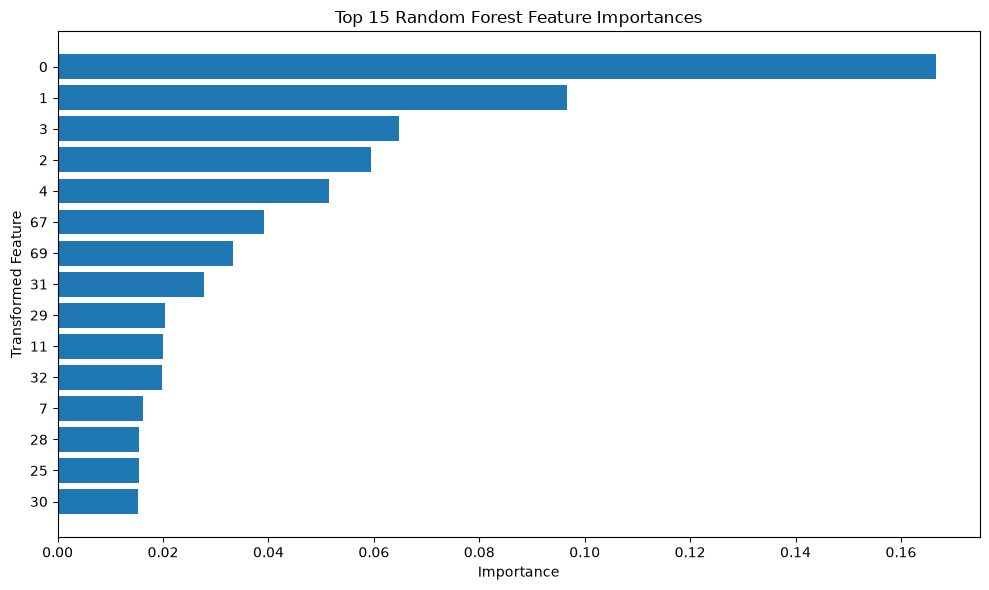

In [102]:
import matplotlib.pyplot as plt

top = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(
    top["feature_number"].astype(str),
    top["importance"]
)
plt.xlabel("Importance")
plt.ylabel("Transformed Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [103]:
print("""
FEATURE IMPORTANCE INTERPRETATION
---------------------------------
The Random Forest identified substantial differences in the
importance of the transformed input features.

The most important transformed feature had an importance of
approximately 0.167, followed by approximately 0.097, 0.065,
and 0.060.

Feature importance was calculated after preprocessing, so the
feature numbers correspond to transformed features rather than
the original dataframe column names.

These results should therefore be interpreted as evidence that
some input variables contribute more strongly to the model's
predictions, rather than as direct evidence of causation.

The model remains limited by its modest ROC-AUC of 0.591.
""")


FEATURE IMPORTANCE INTERPRETATION
---------------------------------
The Random Forest identified substantial differences in the
importance of the transformed input features.

The most important transformed feature had an importance of
approximately 0.167, followed by approximately 0.097, 0.065,
and 0.060.

Feature importance was calculated after preprocessing, so the
feature numbers correspond to transformed features rather than
the original dataframe column names.

These results should therefore be interpreted as evidence that
some input variables contribute more strongly to the model's
predictions, rather than as direct evidence of causation.

The model remains limited by its modest ROC-AUC of 0.591.

